# Which Conditions Fill the Most Hospital Beds, and Why It Isn't the Longest Stays

**Portfolio Project 1 | Descriptive Analytics**

## Overview
Analysis of 100,000 synthetic hospital encounter records. Exploratory workflow, data validation, and statistical framing.

Mean length of stay tells you how long a patient stays in a bed. It doesn't show where bed capacity is actually used. That depends on both how common a condition is and how long its stays run. This project looks at both.


## Research Questions
1. How is length of stay distributed across encounters?
2. Which conditions are associated with longer stays?
3. Is there facility level variation in length of stay?

## Dependencies
Python | pandas | numpy | matplotlib | seaborn | scipy

Install with:
    pip install pandas numpy matplotlib seaborn scipy

## Scope

Descriptive only. See Scope and Limitations for why.


In [ ]:
#Section 1: Setup and Data Loading
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from google.colab import drive
drive.mount('/content/drive')
pd.set_option('display.max_columns',None)
# Update this path to where you've saved the dataset in your Google Drive.
df_raw = pd.read_csv("/content/drive/MyDrive/path/to/Length_of_Stay_Database.csv")

## Section 2: Data Validation

Checks performed:
- Null values across all columns, duplicate encounter IDs (`eid`), and fully duplicated rows
- LOS cross-verification: recalculate from `vdate` / `discharged` and confirm it matches the provided `lengthofstay` column
- LOS range check (min / max / zero-or-negative values)
- `rcount` value distribution (raw, before encoding)

`los_calculated` is added to a temporary validation frame (`df_check`) only. It is NOT carried into the main working dataframe (`df_prep`).

In [ ]:
#Section 2: Data Validation
print(f"Null values per column:{df_raw.isnull().sum().sum()}")
print(f"Duplicate eids:{df_raw['eid'].duplicated().sum()}")
print(f"Fully duplicated rows:{df_raw.duplicated().sum()}")

df_check = df_raw.copy()
df_check['vdate'] = pd.to_datetime(df_check['vdate'])
df_check['discharged'] = pd.to_datetime(df_check['discharged'])
df_check['los_calculated'] = (df_check['discharged'] - df_check['vdate']).dt.days
match = (df_check['los_calculated'] == df_check['lengthofstay']).value_counts()
print(f"LOS verification (calculated vs provided): {match.get(True, 0):,}/{len(df_check):,} match")
print(f"lengthofstay range: {df_raw['lengthofstay'].min()} to {df_raw['lengthofstay'].max()} days")
print(f"Zero or negative values: {(df_raw['lengthofstay'] <= 0).sum()}")

print(f"rcount value distribution: {df_raw['rcount'].value_counts().sort_index()}")

Null values per column:0
Duplicate eids:0
Fully duplicated rows:0
LOS verification (calculated vs provided): 100,000/100,000 match
lengthofstay range: 1 to 17 days
Zero or negative values: 0
rcount value distribution: rcount
0     55031
1     15007
2      9987
3      8047
4      6941
5+     4987
Name: count, dtype: int64


## Section 3: Data Preparation

Steps:
1. Copy raw frame `df_prep` (original is preserved as `df_raw`).
2. Convert `vdate` and `discharged` as datetime.
3. Encode `rcount`: replace `"5+"` with `5`, cast to numeric.
   *Reason:* `"5+"` prevents numeric operations, `5` is a conservative floor.
4. Create `prior_visit_flag` (binary): 1 if `rcount > 0`, else 0.
   *Limitation:* This is a proxy. The dataset has no patient identifier so true readmission rate cannot be computed.
5. Count comorbidities `num_conditions` (sum of 11 binary flags).
6. Bin comorbidities `burden_group` (ordered categorical, strings used to support a "3+" label and preserve chart order).

In [ ]:
#Section 3: Data Preparation
df_prep = df_raw.copy()

df_prep['vdate'] = pd.to_datetime(df_prep['vdate'])
df_prep['discharged'] = pd.to_datetime(df_prep['discharged'])

df_prep['rcount'] = df_prep['rcount'].replace('5+','5')
df_prep['rcount'] = pd.to_numeric(df_prep['rcount'], errors = 'coerce')

df_prep['prior_visit_flag'] = (df_prep['rcount'] > 0).astype(int)
print(f"Prior visit flag rate: {df_prep['prior_visit_flag'].mean()*100:.1f}%")

condition_columns = [
    'dialysisrenalendstage', 'asthma', 'irondef', 'pneum',
    'substancedependence', 'psychologicaldisordermajor',
    'depress', 'psychother', 'fibrosisandother', 'malnutrition', 'hemo'
    ]
df_prep['num_conditions'] = df_prep[condition_columns].sum(axis=1)
print(df_prep['num_conditions'].value_counts().sort_index())

df_prep['burden_group'] = pd.cut(df_prep['num_conditions'], bins=[-1,0,1,2,11], labels = ['0 conditions', '1 condition', '2 conditions', '3+ conditions'])

print(f'Final dataset shape: {df_prep.shape}')
print(f'Total encounters: {len(df_prep):,}')
print()
print('Derived columns added (2 analytical + 1 display only = 3 total):')
print('Analytical:')
print('1. prior_visit_flag: rcount > 0 proxy')
print('2. num_conditions: sum of 11 binary comorbidity flags')
print('Display-only helpers:')
print('3. burden_group: binned version of num_conditions (0/1/2/3+)')

Prior visit flag rate: 45.0%
num_conditions
0    57341
1    23350
2    11536
3     4660
4     2018
5      773
6      261
7       46
8       12
9        3
Name: count, dtype: int64
Final dataset shape: (100000, 31)
Total encounters: 100,000

Derived columns added (2 analytical + 1 display only = 3 total):
Analytical:
1. prior_visit_flag: rcount > 0 proxy
2. num_conditions: sum of 11 binary comorbidity flags
Display-only helpers:
3. burden_group: binned version of num_conditions (0/1/2/3+)


## Section 4: Exploratory Data Analysis

Summaries produced:
- LOS distribution (mean, median, SD, range, tail percentages)
- Condition burden overview (mean conditions, 0 condition,  3+ counts, and per-condition prevalence condition encounter counts, per-condition prevalence rates)
- Facility level LOS summary (encounter count, mean, median, SD by site)
- Per-condition table (Prevalence and mean LOS for each of the 11 conditions. Mean LOS answers "how long" while prevalence answers "how often", both are needed to answer where bed capacity is consumed)

**Note:** Conditions co-occur. An encounter with three flags contributes its full LOS to three rows, so the column ranks conditions by bed-day contribution, not partition total bed-days. The flagged sum (405,592) is near the dataset's true patient-days (400,103) by coincidence:

*57.3% of encounters carry no flags and contribute nothing, roughly cancelling the double-count. Adding the column up and comparing it to the total would be a mistake.*


In [ ]:
#Section 4: Exploratory Data Analysis
print("Length of Stay Summary")
print(f"Mean: {df_prep['lengthofstay'].mean():.1f} days")
print(f"Median: {df_prep['lengthofstay'].median():.1f} days")
print(f"STD Dev: {df_prep['lengthofstay'].std():.1f} days")
print(f"Min: {df_prep['lengthofstay'].min()} days")
print(f"Max: {df_prep['lengthofstay'].max()} days")
print(f"% encounters LOS > 7: {(df_prep['lengthofstay'] > 7).mean()*100:.1f}%")
print(f"% encounters LOS <= 3: {(df_prep['lengthofstay'] <= 3).mean()*100:.1f}%")

print('\nCondition Burden')
print(f"Mean conditions per encounter: {df_prep['num_conditions'].mean():.2f}")
print(f"Encounters with 0 conditions: {(df_prep['num_conditions'] == 0).sum():,}" f"({(df_prep['num_conditions'] == 0).mean()*100:.1f}%)")
print(f"Encounters with 3+ conditions: {(df_prep['num_conditions'] >= 3).sum():,}" f"({(df_prep['num_conditions'] >= 3).mean()*100:.1f}%)")
print(f"\nCondition prevalance (% of encounters):")
for col in condition_columns:
  print(f"{col:<35}{df_prep[col].mean()*100:.1f}%")

facility_stats = (df_prep.groupby('facid')
                  .agg(encounters=('eid', 'count'),
                       mean_los=('lengthofstay', 'mean'),
                       median_los=('lengthofstay', 'median'),
                       std_los=('lengthofstay', 'std'))
                  .reset_index()
                  .sort_values('mean_los', ascending=False))
print(facility_stats.round(2).to_string(index=False))

RENAME = {
    'dialysisrenalendstage':    'Dialysis / Renal',
    'psychologicaldisordermajor': 'Major Psych Disorder',
    'substancedependence':      'Substance Dependence',
    'fibrosisandother':         'Fibrosis & Other',
}
condition_stats = []
for col in condition_columns:
    subset = df_prep[df_prep[col] == 1]
    condition_stats.append({
        'condition':      RENAME.get(col, col.replace('_', ' ').title()),
        'n_encounters':   len(subset),
        'prevalence_pct': round(len(subset) / len(df_prep) * 100, 1),
        'mean_los':       subset['lengthofstay'].mean(),
    })

cond_df = pd.DataFrame(condition_stats).sort_values('mean_los', ascending=True)
print('\nPer-condition mean LOS and prevalence:')
print(cond_df.round(2).to_string(index=False))

# Encounter days by condition flag
burden_days = cond_df.copy()
burden_days['mean_los'] = burden_days['mean_los'].round(2)
burden_days['encounter_days_by_flag'] = (
    burden_days['n_encounters'] * burden_days['mean_los']
).round(0).astype(int)

burden_days = burden_days.sort_values(
    'encounter_days_by_flag', ascending=False
).reset_index(drop=True)

flag_total = burden_days['encounter_days_by_flag'].sum()
burden_days['share_of_flagged_days_pct'] = (
    100 * burden_days['encounter_days_by_flag'] / flag_total
).round(1)

print("\nEncounter-days by condition flag (sorted):")
print(burden_days.to_string(index=False))
print()
print(f"Sum of flagged encounter days: {flag_total:,}")
print(f"Total patient days in dataset:  {df_prep['lengthofstay'].sum():,}")
print("NOTE: the two totals are not comparable. Conditions co-occur, so an")
print("encounter with 3 flags contributes its full LOS to 3 rows. The flagged")
print("sum double counts by design, its not a partition of patient-days.")

Length of Stay Summary
Mean: 4.0 days
Median: 4.0 days
STD Dev: 2.4 days
Min: 1 days
Max: 17 days
% encounters LOS > 7: 8.6%
% encounters LOS <= 3: 46.9%

Condition Burden
Mean conditions per encounter: 0.74
Encounters with 0 conditions: 57,341(57.3%)
Encounters with 3+ conditions: 7,773(7.8%)

Condition prevalance (% of encounters):
dialysisrenalendstage              3.6%
asthma                             3.5%
irondef                            9.5%
pneum                              3.9%
substancedependence                6.3%
psychologicaldisordermajor         23.9%
depress                            5.2%
psychother                         4.9%
fibrosisandother                   0.5%
malnutrition                       4.9%
hemo                               8.0%
facid  encounters  mean_los  median_los  std_los
    E       30755      5.16         5.0     2.08
    C        4699      4.89         5.0     2.09
    D        4499      4.83         4.0     2.09
    B       30012      3.28

## Section 5: Statistical Analysis

Tests performed:
1. **95 % CI for mean LOS**. Manual calculation using z = 1.96
   (sample size n = 100,000 makes the normal approximation valid).
2. **Welch's t-test**. High-burden (≥ 3 conditions) vs low-burden (< 3 conditions) encounters.
3. **Cohen's d** with an n-weighted pooled SD. The groups are imbalanced roughly 12:1 (7,773 vs 92,227).
4. **Pearson and Spearman correlations**. `num_conditions` vs LOS. Close values mean the relationship isn't curved so Pearson's r isn't understating it.

**On the p-value:** at n = 100,000 it underflows to 0.0 and tells you nothing. Any difference is detectable at this sample size, detectability is not importance. Every comparison in this notebook leads with effect size for that reason.


In [ ]:
#Section 5: Statistical Analysis
mean_los = df_prep['lengthofstay'].mean()
std_error = df_prep['lengthofstay'].std()/np.sqrt(len(df_prep))
ci_lower = mean_los - 1.96*std_error
ci_upper = mean_los + 1.96*std_error

print(f"Mean LOS: {mean_los:.2f} days")
print(f"95% CI: [{ci_lower:.3f}, {ci_upper:.3f}] days")

# Hypothesis Test: Condition Burden vs LOS
high_burden = df_prep[df_prep['num_conditions'] >= 3]['lengthofstay']
low_burden = df_prep[df_prep['num_conditions'] < 3]['lengthofstay']

t_stat, p_value = stats.ttest_ind(high_burden, low_burden, equal_var=False)

n1, n2 = len(high_burden), len(low_burden)
pooled_std = np.sqrt(
    ((n1 - 1) * high_burden.std(ddof=1)**2 + (n2 - 1) * low_burden.std(ddof=1)**2)
    / (n1 + n2 - 2)
)
cohens_d = (high_burden.mean() - low_burden.mean())/pooled_std

print(f"High-burden (+3): n={len(high_burden):,}, mean = {high_burden.mean():.2f} days")
print(f"Low-burden (<3): n={len(low_burden):,}, mean = {low_burden.mean():.2f} days")
print(f"Difference: {high_burden.mean() - low_burden.mean():.2f} days")
print(f"t-statistic: {t_stat:.2f}")
print(f"p_value: {p_value:.4e}")
print(f"Significant: {'Yes (p<0.05)' if p_value < 0.05 else 'No'}")
print(f"Group SDs: high-burden = {high_burden.std(ddof=1):.3f}, low-burden = {low_burden.std(ddof=1):.3f}")
print(f"Pooled SD (n-weighted): {pooled_std:.3f}")
print(f"Cohen d: {cohens_d:.3f} (< 0.2 Low | 0.5 Medium | 0.8 Large)")
print(f"\nNote: P-value displays as 0.0 due to floating-point underflow at n=100,000. Effect size (Cohen's d) is the meaningful measure here.")

#Correlation Analysis
r_cond, p_cond = stats.pearsonr(df_prep['num_conditions'], df_prep['lengthofstay'])
print(f"Pearson: num_conditions vs LOS: r = {r_cond:.3f}, p = {p_cond:.4e}")

rho_cond, p_spear = stats.spearmanr(df_prep['num_conditions'], df_prep['lengthofstay'])
print(f"Spearman: num_conditions vs LOS: rho = {rho_cond:.3f}, p = {p_spear:.4e}")
print("If Pearson and Spearman are similar, the linear assumption holds.")

Mean LOS: 4.00 days
95% CI: [3.986, 4.016] days
High-burden (+3): n=7,773, mean = 5.93 days
Low-burden (<3): n=92,227, mean = 3.84 days
Difference: 2.09 days
t-statistic: 78.46
p_value: 0.0000e+00
Significant: Yes (p<0.05)
Group SDs: high-burden = 2.251, low-burden = 2.297
Pooled SD (n-weighted): 2.293
Cohen d: 0.911 (< 0.2 Low | 0.5 Medium | 0.8 Large)

Note: P-value displays as 0.0 due to floating-point underflow at n=100,000. Effect size (Cohen's d) is the meaningful measure here.
Pearson: num_conditions vs LOS: r = 0.417, p = 0.0000e+00
Spearman: num_conditions vs LOS: rho = 0.469, p = 0.0000e+00
If Pearson and Spearman are similar, the linear assumption holds.





## Section 6: Visualisations

Four chart pairs are produced and saved:

**Chart 1: LOS Distribution + Burden Boxplot**

LOS is right-skewed (skewness = 0.63): most stays are short, with a thin tail
of complex cases. Mean and median both land on 4.0 days. The floor at 1 day and ceiling at 17 compress them together despite the skew. The boxplot shows medians stepping up across burden tiers, consistent with the Section 5 test.


**Chart 2: Facility Comparison**

Mean LOS varies meaningfully across sites. This chart reports that variation and stops there. No acuity or case mix adjustment exists in this data, so the spread cannot be attributed to performance.


**Chart 3: Comorbidity Prevalence vs Mean LOS**

The two shown separately. Left panel: which conditions extend stays. Right panel: how common each one is. The panels share an ordering, and comparing them is the point, the ranking doesn't match. Chart 4 resolves what that mismatch means.


**Chart 4: Bed-Days**

Chart 3's two panels, multiplied. Bar length is encounter-days, colour is mean LOS. The inversion is the finding: Fibrosis, longest stays in the dataset, is the shortest bar. Major Psychological Disorder, dominates the axis.


Charts are saved to an `outputs/` folder (created automatically).


LOS skewness: 0.628


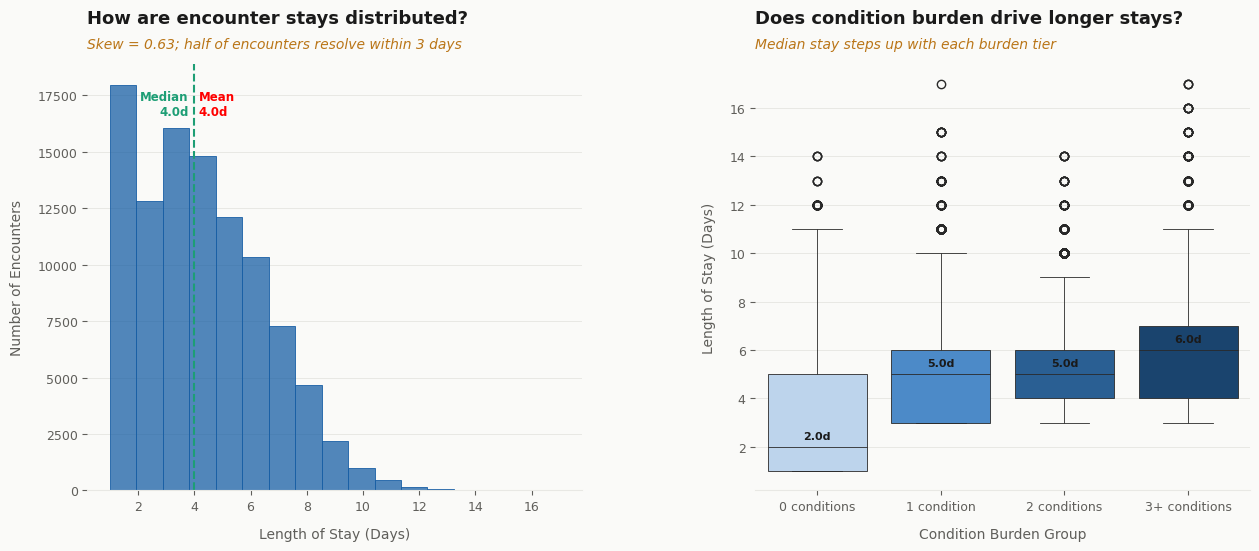

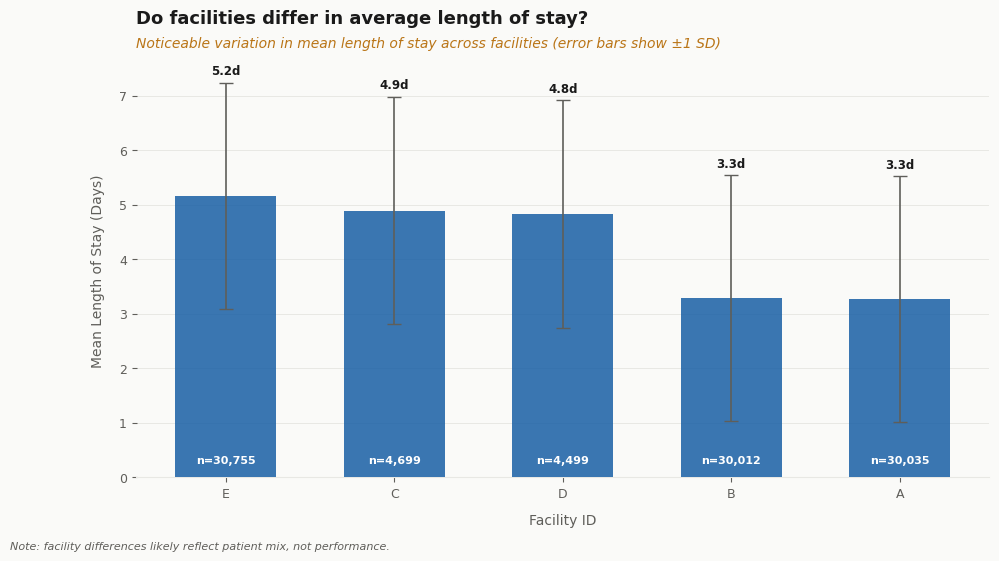

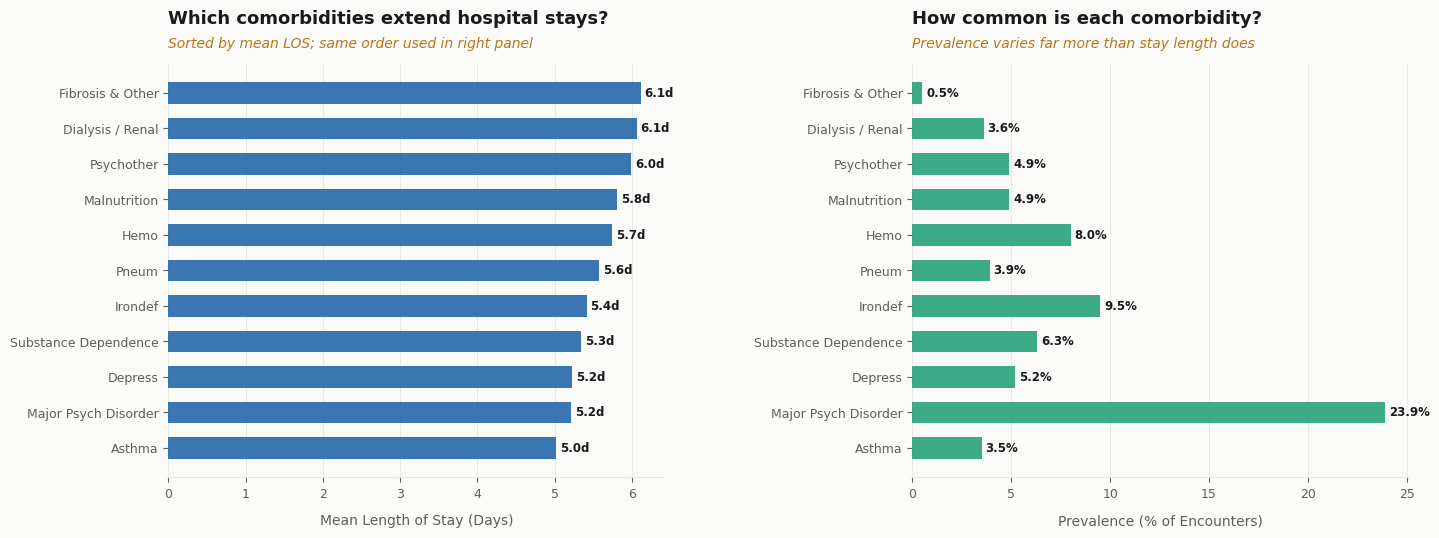

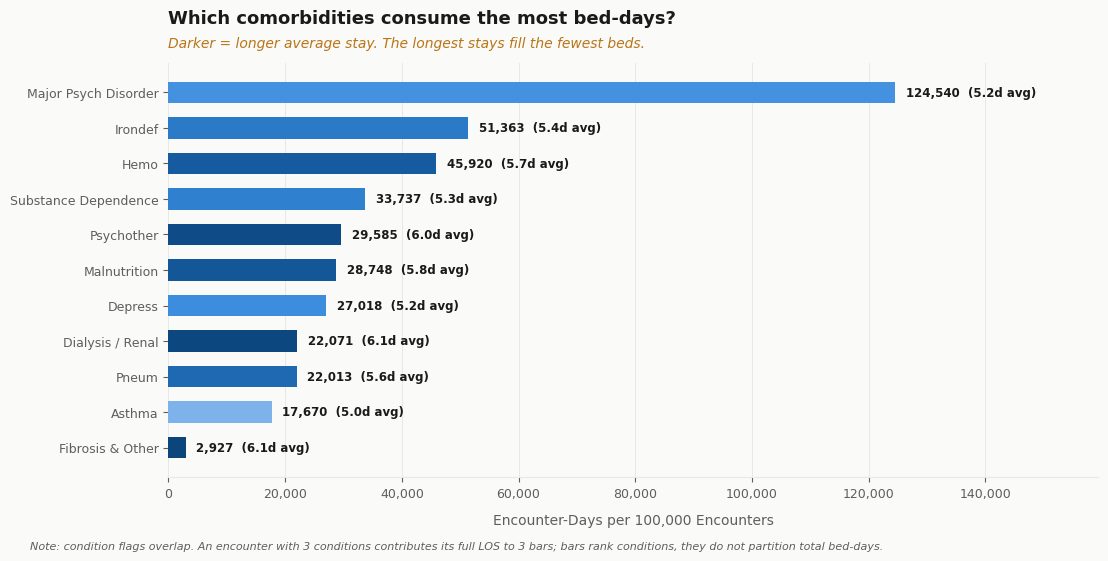

In [18]:
# Section 6: Visualizations
import os
os.makedirs('outputs', exist_ok=True)

#Colors
PRIMARY   = '#185FA5'
ACCENT    = '#1D9E75'
CALLOUT   = '#BA7517'
TEXT      = '#1A1A1A'
MUTED     = '#5F5E5A'
GRID      = '#E8E8E4'
BG        = '#FAFAF8'

BURDEN_PALETTE = ['#B5D4F4', '#378ADD', '#185FA5', '#0C447C']
burden_order   = sorted(df_prep['burden_group'].unique())

def style(ax, title, subtitle, xlabel, ylabel):
    """One call sets title, insight subtitle, axis labels, grid, spines."""
    ax.text(0, 1.13, title,    transform=ax.transAxes, fontsize=13,
            fontweight='bold', color=TEXT, va='top', ha='left')
    ax.text(0, 1.065, subtitle, transform=ax.transAxes, fontsize=10,
            color=CALLOUT, va='top', ha='left', style='italic')
    ax.set_xlabel(xlabel, fontsize=10, color=MUTED, labelpad=10)
    ax.set_ylabel(ylabel, fontsize=10, color=MUTED, labelpad=10)
    ax.tick_params(colors=MUTED, labelsize=9)
    ax.yaxis.grid(True, color=GRID, linewidth=0.7, zorder=0)
    ax.set_axisbelow(True)
    ax.spines[['top', 'right', 'left']].set_visible(False)
    ax.spines['bottom'].set_color(GRID)
    ax.set_facecolor(BG)

#C1: LOS Distribution + Burden Boxplotf
mean_los   = df_prep['lengthofstay'].mean()
median_los = df_prep['lengthofstay'].median()
los_skew   = df_prep['lengthofstay'].skew()
print(f"LOS skewness: {los_skew:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.patch.set_facecolor(BG)
fig.subplots_adjust(wspace=0.35, top=0.82)

sns.histplot(df_prep['lengthofstay'], bins=17, kde=False,
             color=PRIMARY, alpha=0.75, edgecolor=PRIMARY, linewidth=0.6, ax=axes[0])
axes[0].axvline(median_los, color=ACCENT,  linewidth=1.5, linestyle='--')
axes[0].text(median_los - 0.2, axes[0].get_ylim()[1] * 0.88,
             f'Median\n{median_los:.1f}d', fontsize=8.5, color=ACCENT,  fontweight='bold', ha='right')
axes[0].text(mean_los + 0.15, axes[0].get_ylim()[1] * 0.88,
             f'Mean\n{mean_los:.1f}d', fontsize=8.5, color='red',
             fontweight='bold', ha='left')
style(axes[0],
      'How are encounter stays distributed?',
      f'Skew = {los_skew:.2f}; half of encounters resolve within 3 days',
      'Length of Stay (Days)', 'Number of Encounters')

sns.boxplot(x='burden_group', y='lengthofstay', data=df_prep,
            order=burden_order, palette=BURDEN_PALETTE,
            hue='burden_group', hue_order=burden_order, legend=False,
            linewidth=0.6, ax=axes[1])
for i, grp in enumerate(burden_order):
    med = df_prep[df_prep['burden_group'] == grp]['lengthofstay'].median()
    axes[1].text(i, med + 0.25, f'{med:.1f}d',
                 ha='center', va='bottom', fontsize=8, color=TEXT, fontweight='bold')
style(axes[1],
      'Does condition burden drive longer stays?',
      'Median stay steps up with each burden tier',
      'Condition Burden Group', 'Length of Stay (Days)')

plt.savefig('outputs/chart1_los_distribution.png',  dpi=300, bbox_inches='tight', facecolor=BG)
plt.show()


#C2: Facility Comparison
fig, ax = plt.subplots(figsize=(11, 6))
fig.patch.set_facecolor(BG)
fig.subplots_adjust(top=0.80)

ax.bar(range(len(facility_stats)), facility_stats['mean_los'],
       color=PRIMARY, alpha=0.85, zorder=3, width=0.6)
ax.errorbar(range(len(facility_stats)), facility_stats['mean_los'],
            yerr=facility_stats['std_los'],
            fmt='none', capsize=5, color=MUTED, linewidth=1.2, zorder=4)

for i, (_, row) in enumerate(facility_stats.iterrows()):
    ax.text(i, row['mean_los'] + row['std_los'] + 0.15,
            f"{row['mean_los']:.1f}d", ha='center', fontsize=8.5, color=TEXT, fontweight='bold')
    ax.text(i, 0.25, f"n={row['encounters']:,}",
            ha='center', fontsize=8, color='white', fontweight='bold')

ax.set_xticks(range(len(facility_stats)))
ax.set_xticklabels(facility_stats['facid'])
style(ax,
      'Do facilities differ in average length of stay?',
      f'Noticeable variation in mean length of stay across facilities (error bars show ±1 SD)',
      'Facility ID', 'Mean Length of Stay (Days)')
fig.text(0.01, -0.01,
         'Note: facility differences likely reflect patient mix, not performance.',
         fontsize=8, color=MUTED, style='italic')

plt.savefig('outputs/chart2_facility_comparison.png', dpi=300, bbox_inches='tight', facecolor=BG)
plt.show()

#C3: Comorbidity Prevalence & Mean LOS
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor(BG)
fig.subplots_adjust(wspace=0.5, top=0.80)

axes[0].barh(cond_df['condition'], cond_df['mean_los'],
             color=PRIMARY, alpha=0.85, height=0.6)
for i, (_, row) in enumerate(cond_df.iterrows()):
    axes[0].text(row['mean_los'] + 0.05, i, f"{row['mean_los']:.1f}d",
                 va='center', fontsize=8.5, color=TEXT, fontweight='bold')
style(axes[0],
      'Which comorbidities extend hospital stays?',
      'Sorted by mean LOS; same order used in right panel',
      'Mean Length of Stay (Days)', '')
axes[0].xaxis.grid(True, color=GRID, linewidth=0.7)
axes[0].yaxis.grid(False)

axes[1].barh(cond_df['condition'], cond_df['prevalence_pct'],
             color=ACCENT, alpha=0.85, height=0.6)
for i, (_, row) in enumerate(cond_df.iterrows()):
    axes[1].text(row['prevalence_pct'] + 0.2, i, f"{row['prevalence_pct']:.1f}%",
                 va='center', fontsize=8.5, color=TEXT, fontweight='bold')
style(axes[1],
      'How common is each comorbidity?',
      'Prevalence varies far more than stay length does',
      'Prevalence (% of Encounters)', '')
axes[1].xaxis.grid(True, color=GRID, linewidth=0.7)
axes[1].yaxis.grid(False)

plt.savefig('outputs/chart3_comorbidity.png',        dpi=300, bbox_inches='tight', facecolor=BG)
plt.show()

#C4: Encounter Days by Condition Flag
from matplotlib.colors import LinearSegmentedColormap

plot_df = burden_days.sort_values('encounter_days_by_flag', ascending=True)

los_norm = ((plot_df['mean_los'] - plot_df['mean_los'].min()) /
            (plot_df['mean_los'].max() - plot_df['mean_los'].min()))
BLUE_RAMP = LinearSegmentedColormap.from_list('burden_blues', BURDEN_PALETTE)
bar_colors = BLUE_RAMP(0.15 + 0.85 * los_norm)

fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor(BG)
fig.subplots_adjust(top=0.80)

ax.barh(plot_df['condition'], plot_df['encounter_days_by_flag'],
        color=bar_colors, height=0.6, zorder=3)

for i, (_, row) in enumerate(plot_df.iterrows()):
    ax.text(row['encounter_days_by_flag'] + 1800, i,
            f"{row['encounter_days_by_flag']:,}  ({row['mean_los']:.1f}d avg)",
            va='center', fontsize=8.5, color=TEXT, fontweight='bold')

style(ax,
      'Which comorbidities consume the most bed-days?',
      'Darker = longer average stay. The longest stays fill the fewest beds.',
      'Encounter-Days per 100,000 Encounters', '')
ax.xaxis.grid(True, color=GRID, linewidth=0.7)
ax.yaxis.grid(False)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.set_xlim(0, plot_df['encounter_days_by_flag'].max() * 1.28)

fig.text(0.01, -0.01,
         'Note: condition flags overlap. An encounter with 3 conditions contributes its full LOS to 3 bars; '
         'bars rank conditions, they do not partition total bed-days.',
         fontsize=8, color=MUTED, style='italic')

plt.savefig('outputs/chart4_bed_days.png', dpi=300, bbox_inches='tight', facecolor=BG)
plt.show()

## Section 7: Key Findings

### Bed-Days: The Ranking Inverts

- Major Psych Disorder consumes **124,540 encounter-days**, 30.7% of all flagged bed-days, and ~42× more than Fibrosis & Other (2,927).

- Fibrosis has the **longest** mean LOS in the dataset (6.11 days) and the **smallest** bed-day footprint. It appears in 0.5% of encounters.

- Rank by stay length and Fibrosis leads. Rank by beds consumed and it comes last. **Prevalence dominates severity here.**

- *Therefore:* capacity planning on this dataset should track common conditions with unremarkable stays, not rare conditions with long ones.

- **Overlap caveat:** flags co-occur, so these figures rank conditions, they do not partition bed-days. The flagged sum (405,592) is not comparable to the dataset's patient-day total (400,103).

### Condition Burden (The expected result)

- Encounters with 3+ conditions (7.8% of the dataset) average 5.93 days vs 3.84 for the rest: a 2.09-day gap, 54% higher.

- Cohen's d = 0.911, indicates a large difference, using an n-weighted pooled SD across imbalanced groups.

- The p-value underflows to 0.0 at n = 100,000 and is not informative. Effect size is.

- Pearson r = 0.417, Spearman ρ = 0.469. Close enough that the linear read holds.

- Sicker patients stay longer. True, expected, and not actionable on its own.

### Single Conditions vs Co-Occurrence

- Mean LOS by individual condition spans 5.01 (Asthma) to 6.11 days (Fibrosis),
a 1.1-day range.

- The low-vs-high burden gap is 2.09 days, nearly double that spread.

- **How many** conditions an encounter carries moves LOS more than **which** one.

### LOS Distribution

- Mean and median both 4.0 days. SD 2.4, range 1–17, skewness 0.63.

- 46.9% of encounters resolve within 3 days; 8.6% exceed 7.

- 95% CI [3.986, 4.016] is narrow, because n = 100,000 buys precision cheaply. Precision is not the interesting question at this sample size, magnitude is.

### Facility Variation (Reported, not explained)

- Mean LOS runs 3.27 days (A, B) to 5.16 (E), a 58% spread. C and D sit between at 4.89 and 4.83.

- No case mix or acuity adjustment exists in this data. The spread is consistent with differing patient populations and cannot be separated from them.

- No performance claim is made because none is supported.

### Prior visits

- 45.0% of encounters have `rcount` > 0.

- A proxy, not a metric. `rcount` reflects Microsoft's linkage during data generation, that linkage isn't in the released data, so it cannot be independently verified.


## Section 8: Reusable Analysis Function

The summary logic wrapped into one function taking a prepared DataFrame and returning a dict of top-level metrics. Passing `df_prep` reproduces the headline numbers without re-running the notebook, and the same function feeds `summary_stats.csv` in Section 9 so the exported file and the printed output cannot drift apart.


In [ ]:
# Section 8: Reusable Analysis Function

def run_los_summary(df):
    """
    Summarise a prepared hospital LOS DataFrame.
    Expects: lengthofstay, prior_visit_flag, num_conditions columns.
    Returns a dict of key metrics.
    """
    return {
        'total_encounters':     len(df),
        'mean_los':             round(df['lengthofstay'].mean(), 2),
        'median_los':           df['lengthofstay'].median(),
        'std_los':              round(df['lengthofstay'].std(), 2),
        'pct_los_over_7':       round((df['lengthofstay'] > 7).mean() * 100, 1),
        'prior_visit_rate_pct': round(df['prior_visit_flag'].mean() * 100, 1),
        'mean_conditions':      round(df['num_conditions'].mean(), 2),
        'pct_high_burden':      round((df['num_conditions'] >= 3).mean() * 100, 1)
    }

results = run_los_summary(df_prep)
for k, v in results.items():
    print(f'{k:<28} {v}')


total_encounters             100000
mean_los                     4.0
median_los                   4.0
std_los                      2.36
pct_los_over_7               8.6
prior_visit_rate_pct         45.0
mean_conditions              0.74
pct_high_burden              7.8


## Section 9: Export Results

Aggregated tables written to `outputs/` so results are reviewable without executing anything. Three files:

| File | Contents |
|------|----------|
| `summary_stats.csv` | Top-level LOS metrics from `run_los_summary()` |
| `condition_burden_days.csv` | Per-condition prevalence, mean LOS, encounter-days, share     |
| `facility_comparison.csv` | Per-facility encounters, mean LOS, median, SD |


In [12]:
# Section 9: Export Results
import os
os.makedirs('outputs', exist_ok=True)

summary_df = pd.DataFrame([run_los_summary(df_prep)])
summary_df.to_csv('outputs/summary_stats.csv', index=False)
print('Saved: outputs/summary_stats.csv')

burden_days.to_csv('outputs/condition_burden_days.csv', index=False)
print('Saved: outputs/condition_burden_days.csv')

facility_stats.to_csv('outputs/facility_comparison.csv', index=False)
print('Saved: outputs/facility_comparison.csv')

Saved: outputs/summary_stats.csv
Saved: outputs/condition_burden_days.csv
Saved: outputs/facility_comparison.csv


##Scope and Limitations

Each of these is a decision with a reason, not an omission.

- **Descriptive only.** This analysis focuses on summarizing patterns, distributions, and relationships within the dataset. The questions addressed are answerable through descriptive statistics, and a regression model would not provide additional insight for the stated objectives. A descriptive approach is a deliberate analytical choice, not a limitation of the dataset or the analysis.

- **Synthetic data, 2012.** Generated for tutorial use. Every finding describes the dataset's internal structure. None describes a real hospital, and none should be quoted as if it did.

- **No patient identifier.** Encounters cannot be linked to individual patients, so true readmissions cannot be identified or measured. The prior_visit_flag field is therefore treated as a proxy indicator and is labelled as such wherever it is used.

- **Outliers retained.** Stays of 10–17 days are clinically plausible, and date arithmetic confirmed every value is internally consistent. Removing them would delete real cases to tidy a distribution.

- **No condition weighting.** A composite severity score needs clinical weights this dataset can't justify. `num_conditions` counts, it doesn't rank.

- **No cost estimate.** No charge or payer data exists. Any cost figure would be LOS multiplied by an invented rate.

- **Overlapping flags not deduplicated.** Splitting shared bed-days across co-occurring conditions requires an attribution rule the data can't support. Disclosed rather than resolved, `encounter_days_by_flag` ranks conditions, it doesn't partition capacity.

- **No causal claims.** Everything here is correlational, including the facility spread and the burden–LOS relationship.
